In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.4 MB/s eta 0:00:00


In [2]:
# connect colab with drive
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pickle
import sklearn

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/My Drive/YoloFlyCam_Train

/content/drive/My Drive/YoloFlyCam_Train


In [4]:
!yolo version


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.3.230


In [ ]:
!pip install roboflow

from roboflow import Roboflow

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

In [ ]:

rf = Roboflow(api_key="t6A0AnqA90AQETAs4ZBG")
project = rf.workspace("datnguyen-tc9co").project("yolov8_flycam-epq5p")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Yolov8_flycam-2 in yolov8:: 100%|██████████| 2872/2872 [00:22<00:00, 124.97it/s]


In [5]:
!cat data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Human']

roboflow:
  workspace: datnguyen-tc9co
  project: yolov8_flycam-epq5p
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/datnguyen-tc9co/yolov8_flycam-epq5p/dataset/2

In [ ]:
from ultralytics import YOLO
model = YOLO('runs/detect/disaster_aug2/weights/best.pt')

model.train(
    data='data.yaml',  # Path to the training data YAML file
    epochs=150,  # Number of training epochs
    batch=32,  # Batch size for training
    imgsz=640,  # Input image size
    seed=32,  # Random seed for reproducibility
    name= 'disaster_aug_real',
    optimizer='NAdam',  # Optimizer algorithm
    weight_decay=1e-4,  # Weight decay for regularization
    momentum=0.937,  # Initial momentum for the optimizer
    cos_lr=True,  # Use cosine learning rate scheduling
    lr0=0.01,  # Initial learning rate
    lrf=1e-5,  # Final learning rate
    warmup_epochs=10,  # Number of warmup epochs
    warmup_momentum=0.5,  # Momentum during warm-up epochs
    close_mosaic=20,  # Parameter for close mosaic augmentation
    label_smoothing=0.2,  # Label smoothing parameter for regularization
    dropout=0.5,  # Dropout rate to prevent overfitting
    verbose=True  # Print verbose training information
)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.5, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/disaster_aug2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=disaster_aug_real, nbs=64, nms=False, opset=Non

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fec87242540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model = YOLO('runs/detect/disaster_aug_real4/weights/best.pt')
metrics = model.val(data='data.yaml')
print(metrics)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.6±0.9 ms, read: 12.4±9.7 MB/s, size: 51.5 KB)
val: Scanning /content/drive/MyDrive/YoloFlyCam_Train/valid/labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 305.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 5.2s/it 1:29
                   all        260        260       0.87      0.615      0.692      0.406
Speed: 7.4ms preprocess, 316.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/drive/MyDrive/YoloFlyCam_Train/runs/detect/val9
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a5aeedaf8c0>
cur

In [ ]:
#model = YOLO('runs/detect/disaster_aug/weights/best.pt')
model = YOLO('runs/detect/disaster_aug_real4/weights/best.pt')
model.predict(source='test/images', save=True)



image 1/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_001_png.rf.8956e78f93bf9f2878ec964f83397e6d.jpg: 640x640 2 Humans, 249.4ms
image 2/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_002_png.rf.dccd9bf79c0a2368284c3cf114a454cd.jpg: 640x640 1 Human, 218.7ms
image 3/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_003_png.rf.aeea99e8ca37f16c6ffbfa0508d7c014.jpg: 640x640 1 Human, 231.5ms
image 4/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_004_png.rf.c0c4898a040c26bfea54f78f9dca0b78.jpg: 640x640 1 Human, 408.8ms
image 5/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_005_png.rf.4755dcbe27fc97b8e29579e96b5e8a68.jpg: 640x640 (no detections), 236.8ms
image 6/332 /content/drive/MyDrive/YoloFlyCam_Train/test/images/0_Child_collaspe_006_png.rf.ac97ad700c1d82d58a53defc9d064cca.jpg: 640x640 1 Human, 220.3ms
image 7/332 /content/drive/MyDrive/YoloFlyCam_Train/test/ima

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Human'}
 obb: None
 orig_img: array([[[ 72, 106,  82],
         [ 61,  95,  71],
         [ 49,  84,  58],
         ...,
         [ 40,  79,  64],
         [ 15,  52,  36],
         [ 22,  58,  41]],
 
        [[ 65,  97,  73],
         [ 53,  87,  63],
         [ 46,  78,  53],
         ...,
         [ 56,  97,  82],
         [ 43,  80,  64],
         [ 22,  60,  42]],
 
        [[ 69,  98,  75],
         [ 59,  91,  67],
         [ 53,  82,  59],
         ...,
         [ 62, 102,  90],
         [ 42,  83,  68],
         [ 23,  62,  46]],
 
        ...,
 
        [[ 41,  71,  46],
         [ 38,  68,  43],
         [ 42,  71,  48],
         ...,
         [  6,  30,  22],
         [ 11,  38,  28],
         [ 14,  44,  33]],
 
        [[ 42,  72,  47],
         [ 39,  69,  44],
         [ 42,  72,  47],
         ...,
         [  4,  28,

In [ ]:
import pandas as pd

df = pd.read_csv('runs/detect/disaster_aug/results.csv')
print(df.head())



   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  16.2305         3.78689        13.75350         3.57898   
1      2  25.6272         3.37138         7.44767         3.14093   
2      3  38.7758         2.83570         3.98350         2.50142   
3      4  51.9344         2.66473         3.03351         2.27034   
4      5  64.2460         2.49501         2.80097         2.04340   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.09715            0.13333           0.02826   
1               0.09229            0.11111           0.03596   
2               0.48954            0.14928           0.16252   
3               0.49812            0.13333           0.14047   
4               0.79345            0.14444           0.15061   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.01130       3.00532       5.87845       2.83927  0.000600   
1              0.01451       2.68203       4

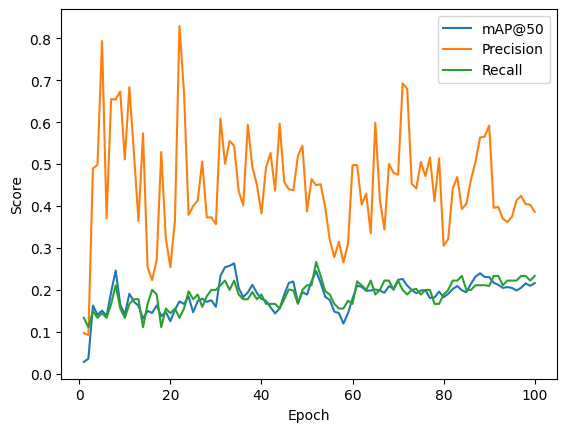

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.show()

In [ ]:
# Nạp model đã train xong
from ultralytics import YOLO
model = YOLO('runs/detect/disaster_aug2/weights/best.pt')

# Xuất sang ONNX với opset=9 và simplify=True
model.export(format='onnx', opset=9, simplify=True)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/disaster_aug2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

ONNX: starting export with onnx 1.19.1 opset 9...
ONNX: slimming with onnxslim 0.1.74...
ONNX: export success ✅ 1.3s, saved as 'runs/detect/disaster_aug2/weights/best.onnx' (11.7 MB)

Export complete (1.9s)
Results saved to /content/drive/MyDrive/YoloFlyCam_Train/runs/detect/disaster_aug2/weights
Predict:         yolo predict task=detect model=runs/detect/disaster_aug2/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs/detect/disaster_aug2/weights/best.onnx imgsz=640 data=data.yaml  
Visualize:       https://netron.app


'runs/detect/disaster_aug2/weights/best.onnx'

In [ ]:
# Recommend using python virtual environment
!pip install onnx
!pip install onnxruntime



In [ ]:
# In general,
# Use --optimization_style Runtime, when running on mobile GPU
# Use --optimization_style Fixed, when running on mobile CPU
!python -m onnxruntime.tools.convert_onnx_models_to_ort best_unity_enhance.onnx --optimization_style Runtime

Converting models with optimization style 'Runtime' and level 'all'
Converting optimized ONNX model /content/drive/MyDrive/YoloFlyCam_Train/best_unity_enhance.onnx to ORT format model /content/drive/MyDrive/YoloFlyCam_Train/best_unity_enhance.with_runtime_opt.ort
Converted 1/1 models successfully.
Converting models again without runtime optimizations to generate a complete config file. These converted models are temporary and will be deleted.
Converting optimized ONNX model /content/drive/MyDrive/YoloFlyCam_Train/best_unity_enhance.onnx to ORT format model /content/drive/MyDrive/YoloFlyCam_Train/tmp_t385yqa.without_runtime_opt/best_unity_enhance.ort
Converted 1/1 models successfully.
Generating config file from ORT format models with optimization style 'Runtime' and level 'all'
2025-11-16 17:39:31,395 ort_format_model.utils [INFO] - Created config in /content/drive/MyDrive/YoloFlyCam_Train/best_unity_enhance.required_operators.with_runtime_opt.config


In [ ]:

!yolo export model=best.pt format=onnx opset=9 imgsz=640 simplify=True dynamic=False

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 955, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 81, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 149, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 288, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 1461, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^^

In [ ]:
pip install ultralytics onnx

In [ ]:
from IPython.display import Image, display

# Xem kết quả tổng hợp
display(Image(filename='/content/drive/My Drive/YoloFlyCam_Train/runs/detect/val/BoxF1_.png'))

# (Tùy chọn) xem ma trận nhầm lẫn
display(Image(filename='/content/drive/My Drive/YoloFlyCam_Train/runs/detect/trvalain/confusion_matrix.png'))


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/YoloFlyCam_Train/runs/detect/train/results.png'